# Bài tập Buổi 5 — Pipeline Machine Learning: EDA & Tiền xử lý trên Titanic

**Khóa học hè 2026 — Python & Machine Learning · ML IoT Lab, HCMUT**

---

## Bối cảnh

Bạn vừa nhận được dataset **Titanic** — danh sách hành khách và việc họ có sống sót sau thảm họa hay không.
Nhiệm vụ của bạn **không phải** huấn luyện mô hình, mà là hoàn thành **hai bước đầu và quan trọng nhất** của một dự án Machine Learning:

> **Khám phá dữ liệu (EDA) → Tiền xử lý dữ liệu.**

Đây là phần chiếm ~70–90% công sức thực tế của một dự án ML. Một mô hình mạnh không thể cứu một bộ dữ liệu kém chất lượng.

## Mục tiêu bài tập

Sau khi hoàn thành, bạn sẽ chứng minh được rằng mình có thể:

1. Thực hiện **EDA đầy đủ** trên một dataset thực tế: kiểm tra cấu trúc, giá trị thiếu, outlier, phân phối và tương quan.
2. **Trực quan hóa** dữ liệu và **rút ra nhận xét có căn cứ** (không chỉ vẽ hình cho đẹp).
3. Áp dụng **đúng kỹ thuật tiền xử lý** cho từng loại dữ liệu: xử lý missing, encoding, scaling.
4. Chia tập và xây pipeline tiền xử lý **không rò rỉ dữ liệu (data leakage)**.
5. Viết **nhận xét tổng hợp** về dữ liệu như một data analyst thực thụ.

## Yêu cầu nộp bài

- Hoàn thiện notebook này (điền vào tất cả các ô `# TODO` và các phần *"Trả lời:"*).
- Notebook phải **chạy được từ trên xuống dưới không lỗi** (Kernel → Restart & Run All).
- Nộp qua **GitHub**: tải repo mẫu → đưa lên repo cá nhân → làm bài và nộp trên đó.

## Tiêu chí chấm (10 điểm)

| Nội dung | Điểm |
|---|---|
| EDA đầy đủ (shape/info/missing/outlier) | 2.0 |
| Trực quan hóa + nhận xét cho mỗi biểu đồ | 2.0 |
| Xử lý missing & outlier hợp lý, có giải thích | 1.5 |
| Encoding & scaling đúng loại biến | 1.5 |
| Chia tập & tiền xử lý **không leakage** | 1.5 |
| Nhận xét tổng hợp về dữ liệu | 1.5 |

> **Lưu ý về liêm chính học thuật:** được tham khảo tài liệu, nhưng phải **tự viết code và tự hiểu**. Phần nhận xét phải là quan sát của chính bạn từ dữ liệu.

---


**Họ và Tên: Nguyễn Long Thiên**

**MSSV: 25122089**

## 0. Chuẩn bị môi trường

Ô này đã viết sẵn — chạy để nạp thư viện. Nếu thiếu thư viện, cài bằng `pip install pandas numpy matplotlib seaborn scikit-learn`.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


## 1. Tải dữ liệu (đã cho)

Ô này đã viết sẵn. Dữ liệu được tải từ `seaborn`, có fallback tải từ Internet nếu cần.

In [4]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df.head()

Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## Task 1 — Loại bỏ cột rò rỉ nhãn (data leakage) và cột dư thừa

### Mục đích
Trên slide đã học: **data leakage** là khi thông tin không được phép "rò" vào mô hình, khiến kết quả đẹp trên giấy nhưng vô dụng thực tế. Bản Titanic của seaborn chứa sẵn nhiều cột **rò rỉ nhãn** hoặc **trùng lặp**:

- `alive` (yes/no) — chính là `survived` viết bằng chữ ⇒ **rò rỉ target trực tiếp**. Để lại là mô hình "gian lận".
- `who`, `adult_male`, `class` — được suy ra từ `sex`, `age`, `pclass` (trùng thông tin).
- `deck` — thiếu quá nhiều (~77%).
- `embark_town` — trùng `embarked`; `alone` — suy ra từ `sibsp` + `parch`.

### Yêu cầu
1. In ra danh sách cột và tỷ lệ missing của **toàn bộ** dataframe (để thấy `deck` thiếu bao nhiêu).
2. Loại bỏ các cột rò rỉ / dư thừa ở trên, chỉ giữ lại:
   `survived, pclass, sex, age, sibsp, parch, fare, embarked`.
3. **Trả lời** (markdown ô dưới): vì sao để lại cột `alive` sẽ khiến mô hình đạt accuracy ~100% mà không thực sự học được gì?

### Gợi ý
- `df.isnull().mean()` cho tỷ lệ thiếu theo cột.
- `df.drop(columns=[...])` để bỏ cột.

In [8]:
print("Tỉ lệ mising của từng cột:")
print(df.isnull().mean())
leaky = ["alive","who","adult_male","class","deck","embark_town","alone"]
df = df.drop(columns=leaky, errors='ignore')
print("\nCác cột còn lại sau khi lọc:", list(df.columns))

Tỉ lệ mising của từng cột:
survived       0.000000
pclass         0.000000
sex            0.000000
age            0.198653
sibsp          0.000000
parch          0.000000
fare           0.000000
embarked       0.002245
class          0.000000
who            0.000000
adult_male     0.000000
deck           0.772166
embark_town    0.002245
alive          0.000000
alone          0.000000
dtype: float64

Các cột còn lại sau khi lọc: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


**Trả lời 1c (vì sao `alive` gây rò rỉ target):**

Cột `alive` và `survived` cùng biểu diễn một thông tin (sống/chết). Nếu giữ lại, mô hình sẽ chỉ học vẹt mối tương quan hoàn hảo này để đạt Accuracy ~100% khi test. Tuy nhiên, khi dự đoán thực tế cho hành khách mới, cột `alive` chưa tồn tại, khiến mô hình bị vô hiệu hóa vì không học cách liên kết các đặc trưng thực tế khác (như tuổi, giới tính, hạng vé) với khả năng sống sót.


---
## Task 2 — Quan sát tổng quan

### Mục đích
Trước khi phân tích sâu, phải nắm được "hình dạng" của dữ liệu: bao nhiêu mẫu, bao nhiêu đặc trưng, kiểu dữ liệu từng cột, và thống kê cơ bản. Đây là bước đầu tiên của mọi EDA.

### Yêu cầu
1. In **số dòng và số cột**; nêu rõ đâu là **biến mục tiêu (target)**.
2. Dùng `df.info()` để xem kiểu dữ liệu và số giá trị non-null.
3. Dùng `df.describe()` cho biến số và `df.describe(include="object")` (hoặc `"category"`) cho biến phân loại.
4. **Trả lời:** cột nào là biến **số**, cột nào là biến **phân loại**?

In [15]:
print(f"Số dòng (số mẫu): {df.shape[0]}")
print(f"Số cột (số thuộc tính): {df.shape[1]}")
print("Biến mục tiêu (Target variable): 'survived' (0: Không sống sót, 1: Sống sót)")
print("=" * 50)
print("Thông tin cấu trúc DataFrame:")
df.info()
print("=" * 50)
print("Thống kê mô tả cho các biến số (Numerical):")
print(df.describe(include=['object', 'category']))
print("-" * 50)
print("Thống kê mô tả cho các biến phân loại (Categorical):")
print(df.describe(include=['object', 'category']))


Số dòng (số mẫu): 891
Số cột (số thuộc tính): 8
Biến mục tiêu (Target variable): 'survived' (0: Không sống sót, 1: Sống sót)
Thông tin cấu trúc DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    str    
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 55.8 KB
Thống kê mô tả cho các biến số (Numerical):
         sex embarked
count    891      889
unique     2        3
top     male        S
freq     577      644
--------------------------------------------------
Thống kê mô tả cho các biến phân loại (Categorical):
         sex embarked
count    891      889
u

/tmp/ipykernel_24412/1243333485.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include=['object', 'category']))
/tmp/ipykernel_24412/1243333485.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for d

**Trả lời 2 (biến số vs biến phân loại):**

**Biến số**:
age (Biến số liên tục - số tuổi của hành khách).


fare (Biến số liên tục - giá vé tàu).

sibsp (Biến số rời rạc - số anh chị em/vợ chồng đi cùng).

parch (Biến số rời rạc - số cha mẹ/con cái đi cùng).


**Biến phân loại (Categorical Variables)**:
sex (Biến phân loại định danh - giới tính: male/female).

embarked (Biến phân loại định danh - cảng lên tàu: C, Q, S).


 

---
## Task 3 — Missing Value: thống kê & đề xuất cách xử lý

### Mục đích
Mô hình học máy **không nhận trực tiếp giá trị NaN**. Nhưng cách xử lý phụ thuộc **tỷ lệ thiếu** và **vai trò của cột** — không có một cách đúng cho mọi trường hợp.

### Yêu cầu
1. Lập bảng: mỗi cột còn missing → **số lượng** và **phần trăm** thiếu.
2. Với **từng cột** còn thiếu, **đề xuất** cách xử lý và **giải thích ngắn gọn** (xóa / điền mean / điền median / điền mode / KNN...).

### Gợi ý
- Nhắc lại từ slide: `median` bền vững hơn `mean` khi có outlier; cột thiếu quá nhiều (>~60–70%) thường nên **bỏ**; biến phân loại thường điền **mode**.

In [17]:
missing_count = df.isnull().sum()
missing_percent = (df.isnull().mean() * 100).round(2)
missing_summary = pd.DataFrame({
    'Số lượng thiếu': missing_count,
    'Phần trăm thiếu (%)': missing_percent
})
missing_summary = missing_summary[missing_summary['Số lượng thiếu'] > 0]
print(missing_summary)

          Số lượng thiếu  Phần trăm thiếu (%)
age                  177                19.87
embarked               2                 0.22


**Trả lời 3 (đề xuất xử lý cho từng cột thiếu):**

| Cột | % thiếu | Cách xử lý đề xuất | Lý do |
|---|---|---|---|
| `age` | ~19.87% | Điền bằng trung vị (`median`) | Cột `age` là biến số liên tục và có thể có các giá trị ngoại lệ (outlier). Sử dụng `median` sẽ bền vững (robust) hơn `mean` do không bị ảnh hưởng bởi outlier. Tỷ lệ thiếu ~20% là mức trung bình, nên điền khuyết hơn là xóa dòng/cột. |
| `embarked` | ~0.22% | Điền bằng yếu vị (`mode` - cảng phổ biến nhất là 'S') hoặc xóa 2 dòng thiếu này. | Cột `embarked` là biến phân loại nên không thể dùng `mean`/`median`. Số lượng thiếu cực kỳ ít (chỉ 2 dòng trên 891 mẫu ~0.22%), việc điền `mode` hoặc xóa hẳn 2 dòng này đều không ảnh hưởng tới chất lượng tổng thể của mô hình. |


---
## Task 4 — Phát hiện Outlier & **ra quyết định**

### Mục đích
Outlier có thể là **lỗi nhập liệu** (cần xử lý) hoặc **hiện tượng thật** (cần giữ). Phát hiện thôi chưa đủ — một analyst giỏi phải **quyết định** làm gì và giải thích được.

### Yêu cầu
1. Trên hai cột `age` và `fare`, đếm số outlier bằng **cả hai** phương pháp: **IQR** và **Z-score** (ngưỡng |z| > 3).
2. **Trả lời:** với các outlier của `fare`, bạn **giữ lại hay loại bỏ**? Vì sao? (gợi ý: nghĩ xem vé đắt bất thường là lỗi hay là vé hạng nhất có thật).

### Gợi ý
- IQR: outlier là điểm ngoài khoảng `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
- Z-score: `from scipy import stats; np.abs(stats.zscore(series.dropna()))`.

In [18]:
def dem_outlier_iqr(s):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return ((s < lower_bound) | (s > upper_bound)).sum()

def dem_outlier_zscore(s, nguong=3.0):
    s_clean = s.dropna() 
    z = np.abs(stats.zscore(s_clean))
    return (z > nguong).sum()

for col in ["age", "fare"]:
    n_iqr = dem_outlier_iqr(df[col])
    n_z = dem_outlier_zscore(df[col])
    print(f"Cột '{col}':")
    print(f"  - Số lượng outlier theo IQR: {n_iqr}")
    print(f"  - Số lượng outlier theo Z-score: {n_z}")


Cột 'age':
  - Số lượng outlier theo IQR: 11
  - Số lượng outlier theo Z-score: 2
Cột 'fare':
  - Số lượng outlier theo IQR: 116
  - Số lượng outlier theo Z-score: 20


**Trả lời 4:**

Tôi quyết định **GIỮ LẠI** các outlier của cột `fare` vì:

1. **Là giá trị thực tế:** Vé đắt đỏ (lên tới >500 USD) của phòng hạng sang (VIP) là có thật, không phải lỗi nhập liệu.
2. **Chứa thông tin quan trọng:** Nhóm mua vé đắt có tỷ lệ sống sót cao hơn rõ rệt. Xóa đi sẽ làm mất tín hiệu dự đoán quan trọng của mô hình.
3. **Hướng xử lý:** Nên dùng `RobustScaler` hoặc biến đổi log (`np.log1p(fare)`) để giảm độ lệch (skewness) thay vì xóa bỏ.


---
## Task 5 — Trực quan hóa & nhận xét

### Mục đích
EDA là môn học về **nhìn** dữ liệu. Mỗi biểu đồ phải trả lời một câu hỏi và **đi kèm một nhận xét**. Vẽ mà không nhận xét thì không tính điểm.

### Yêu cầu — vẽ tối thiểu 4 loại biểu đồ, mỗi biểu đồ 1–2 câu nhận xét:
1. **Univariate — Histogram**: phân phối của `age` và `fare`. (Nhận xét: có lệch không? lệch trái hay phải?)
2. **Univariate — Boxplot**: `fare` theo nhóm `survived` hoặc `pclass`. (Nhận xét: outlier, trung vị.)
3. **Bivariate — Bar/Barplot**: **tỷ lệ sống sót** theo `sex` và theo `pclass`. (Nhận xét: nhóm nào sống nhiều hơn, chênh bao nhiêu %?)
4. **Multivariate — Heatmap**: ma trận tương quan giữa các biến số. (Nhận xét: cặp biến nào tương quan mạnh?)

### Gợi ý
- `sns.histplot`, `sns.boxplot`, `sns.barplot(data=df, x="sex", y="survived")` (barplot tự tính trung bình = tỷ lệ sống sót), `sns.heatmap(df.select_dtypes("number").corr(), annot=True)`.

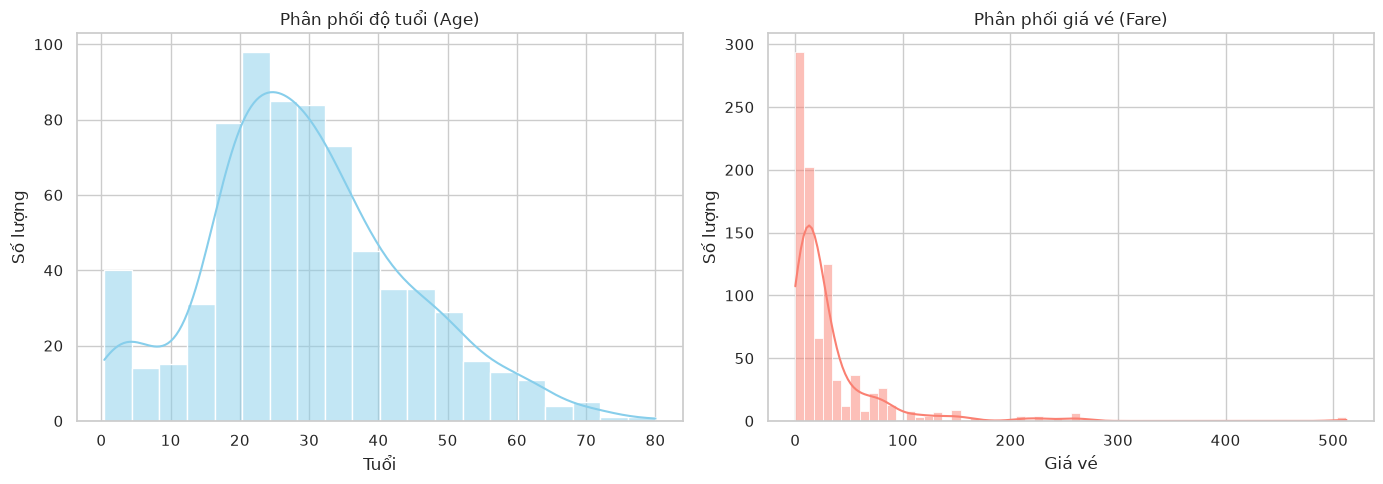

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x="age", kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Phân phối độ tuổi (Age)")
axes[0].set_xlabel("Tuổi")
axes[0].set_ylabel("Số lượng")

sns.histplot(data=df, x="fare", kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Phân phối giá vé (Fare)")
axes[1].set_xlabel("Giá vé")
axes[1].set_ylabel("Số lượng")

plt.tight_layout()
plt.show()


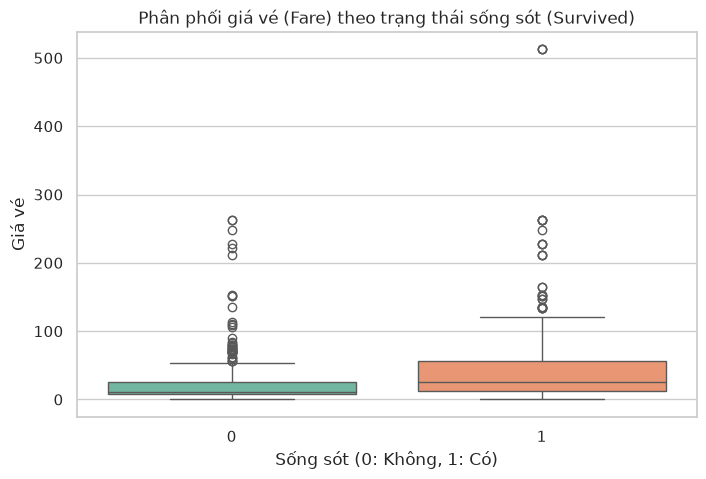

In [24]:
plt.figure(figsize=(8, 5))
 
sns.boxplot(data=df, x="survived", y="fare", hue="survived", palette="Set2", legend=False)
plt.title("Phân phối giá vé (Fare) theo trạng thái sống sót (Survived)")
plt.xlabel("Sống sót (0: Không, 1: Có)")
plt.ylabel("Giá vé")
plt.show()


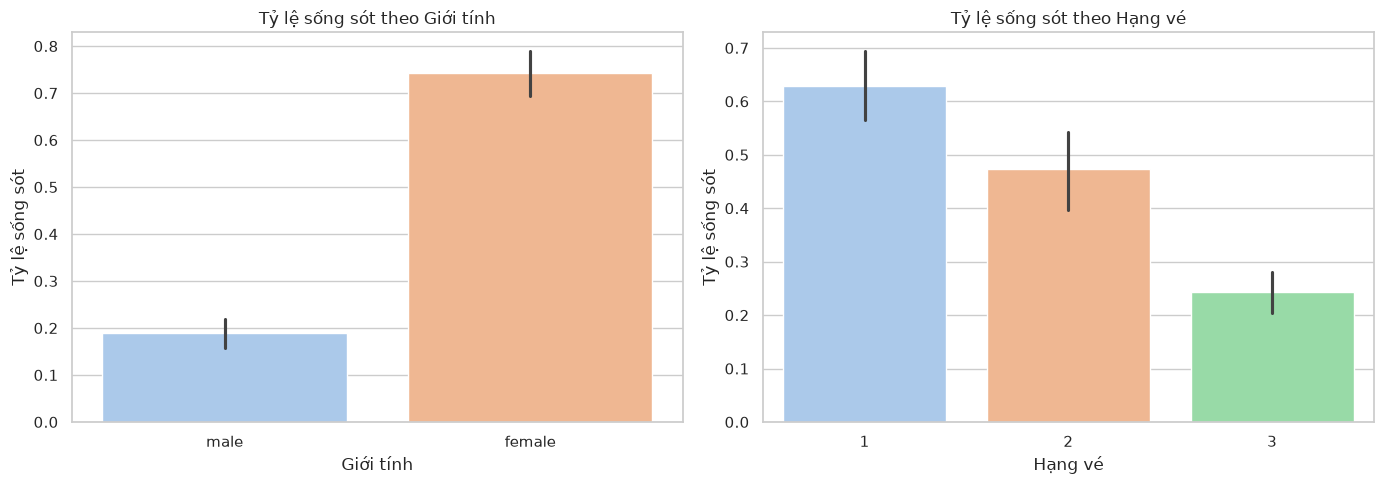

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tỷ lệ sống sót theo giới tính (Sex) - Thêm hue="sex" và legend=False
sns.barplot(data=df, x="sex", y="survived", hue="sex", ax=axes[0], palette="pastel", legend=False)
axes[0].set_title("Tỷ lệ sống sót theo Giới tính")
axes[0].set_xlabel("Giới tính")
axes[0].set_ylabel("Tỷ lệ sống sót")

# Tỷ lệ sống sót theo hạng vé (Pclass) - Thêm hue="pclass" và legend=False
sns.barplot(data=df, x="pclass", y="survived", hue="pclass", ax=axes[1], palette="pastel", legend=False)
axes[1].set_title("Tỷ lệ sống sót theo Hạng vé")
axes[1].set_xlabel("Hạng vé")
axes[1].set_ylabel("Tỷ lệ sống sót")

plt.tight_layout()
plt.show()


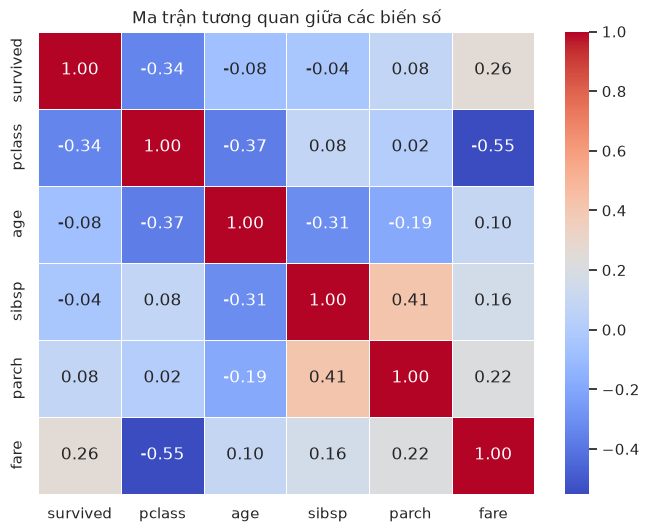

In [ ]:
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=["number"])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Ma trận tương quan giữa các biến số")
plt.show()


**Nhận xét 5:**

*   **Histogram:** `age` phân phối gần chuẩn (tập trung ở 20-40 tuổi); `fare` lệch phải rất mạnh (đa số giá vé rẻ <50 USD).
*   **Boxplot:** Nhóm sống sót có giá vé trung vị cao hơn rõ rệt và có nhiều giá trị ngoại lệ (outlier) cực lớn.
*   **Bar survival:** Nữ giới sống sót nhiều hơn Nam giới (~74% vs ~19%); hạng vé càng cao tỷ lệ sống sót càng lớn (Hạng 1 ~63% vs Hạng 3 ~24%).
*   **Heatmap:** Tương quan âm mạnh giữa `pclass` và `fare` (-0.55); khả năng sống sót (`survived`) tăng khi hạng vé VIP hơn (tương quan âm với `pclass`: -0.34) và giá vé đắt hơn (tương quan dương với `fare`: 0.26).


---
## Task 6 — Chia tập **TRƯỚC** khi tiền xử lý (chống data leakage)

### Mục đích
Đây là điểm mấu chốt của buổi học. Mọi phép "học tham số" từ dữ liệu (median để điền, min/max/IQR để scale, danh mục để encode) **chỉ được học từ tập train**. Nếu học từ toàn bộ dữ liệu rồi mới chia, thông tin của tập test đã **rò rỉ** — điểm đánh giá sẽ ảo.

⇒ **Vì vậy phải chia tập TRƯỚC**, rồi mới xử lý.

### Yêu cầu
1. Tách `X` (đặc trưng) và `y` (`survived`).
2. Chia **train / validation / test** theo tỷ lệ khoảng **70 / 15 / 15**, có **`stratify=y`** để giữ nguyên tỷ lệ hai lớp.
3. In shape của 3 tập và **tỷ lệ sống sót** trong mỗi tập (để kiểm tra stratify hoạt động).

### Gợi ý
- Dùng `train_test_split` **hai lần**: lần 1 tách test (15%), lần 2 tách val từ phần còn lại.
- `stratify` nhận vào nhãn tương ứng ở mỗi lần chia.

In [26]:
# TODO 6: chia train/val/test có stratify
X = df.drop(columns=["survived"])
y = df["survived"]

# Lần 1: Tách riêng tập Test (15% trên tổng số mẫu)
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Lần 2: Tách tập Val (15% trên tổng số, tương đương 15/85 phần còn lại) và Train (70%) từ X_tmp
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=15/85, random_state=42, stratify=y_tmp
)

# In kích thước các tập dữ liệu
print(f"Kích thước Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# In tỷ lệ sống sót để kiểm tra phân tầng (stratify) hoạt động đồng đều
print(f"Tỷ lệ sống sót trong Train: {y_train.mean():.4f}")
print(f"Tỷ lệ sống sót trong Val:   {y_val.mean():.4f}")
print(f"Tỷ lệ sống sót trong Test:  {y_test.mean():.4f}")


Kích thước Train: (623, 7), Val: (134, 7), Test: (134, 7)
Tỷ lệ sống sót trong Train: 0.3836
Tỷ lệ sống sót trong Val:   0.3881
Tỷ lệ sống sót trong Test:  0.3806


---
## Task 7 — Xây pipeline tiền xử lý, **fit chỉ trên train**

### Mục đích
Gộp toàn bộ bước tiền xử lý vào một `ColumnTransformer` + `Pipeline`, `fit` **một lần trên `X_train`** rồi `transform` cho val/test. Đây là cách chuẩn để **đảm bảo không leakage** và tái sử dụng được.

### Yêu cầu
Xây `preprocess` gồm:

- **Biến số** (`age`, `sibsp`, `parch`, `fare`): `SimpleImputer(median)` → scaler (chọn `RobustScaler` vì `fare` có outlier, hoặc giải thích lựa chọn khác).
- **Biến phân loại** (`sex`, `embarked`): `SimpleImputer(most_frequent)` → `OneHotEncoder`.
- **Biến thứ tự** (`pclass`): giữ nguyên (`passthrough`) vì đã là số có thứ tự 1 < 2 < 3.

Sau đó: `fit` trên `X_train`, `transform` cho cả ba tập; in shape kết quả và tên cột sau biến đổi.

### Yêu cầu trả lời
- **Trả lời:** giải thích vì sao `fit` chỉ trên train (không phải trên toàn bộ dữ liệu) thì tránh được leakage.

### Gợi ý
- Khung `ColumnTransformer([... ("num", pipe_so, num_cols), ("cat", pipe_cat, cat_cols), ("ord", "passthrough", ord_cols)])`.
- `preprocess.get_feature_names_out()` để xem tên cột sau biến đổi.

In [27]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

# TODO 7: xây pipeline cho biến số và biến phân loại
pipe_so  = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  RobustScaler()),
])

pipe_cat = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocess = ColumnTransformer([
    ("num", pipe_so,  num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols),
])

# fit CHỈ trên tập train
preprocess.fit(X_train)

# transform  lên cả ba tập
X_train_t = preprocess.transform(X_train)
X_val_t   = preprocess.transform(X_val)
X_test_t  = preprocess.transform(X_test)

print("Kích thước tập train sau biến đổi:", X_train_t.shape)
print("Các cột mới sau biến đổi:\n", list(preprocess.get_feature_names_out()))


Kích thước tập train sau biến đổi: (623, 10)
Các cột mới sau biến đổi:
 ['num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_female', 'cat__sex_male', 'cat__embarked_C', 'cat__embarked_Q', 'cat__embarked_S', 'ord__pclass']


**Trả lời 7:**

*   **Bản chất `fit`:** Tính toán và học các tham số thống kê (như `median`, `IQR`) từ dữ liệu.
*   **Tránh Data Leakage:** Nếu `fit` trên toàn bộ dữ liệu, thông tin của tập Val/Test sẽ bị rò rỉ vào quá trình tiền xử lý, làm kết quả đánh giá mô hình bị ảo.
*   **Chỉ `fit` trên Train:** Giúp tập Val/Test giữ nguyên vai trò là dữ liệu mới hoàn toàn, chỉ được biến đổi (`transform`) theo các tham số đã học từ Train.


---
## Task 8 — Câu hỏi tư duy: chọn metric đánh giá

### Mục đích
Buổi học nhấn mạnh: **không có metric tốt nhất tuyệt đối** — phải chọn theo bài toán và mức mất cân bằng dữ liệu. Bài này không cần code, chỉ cần lập luận.

### Yêu cầu — trả lời ngắn gọn:
1. Biến mục tiêu `survived` có **mất cân bằng** không? (tính tỷ lệ hai lớp để trả lời).
2. Nếu chỉ nhìn **Accuracy**, có thể bị đánh lừa trong trường hợp nào?
3. Với bài toán Titanic, bạn sẽ ưu tiên metric nào (Accuracy / Precision / Recall / F1)? Vì sao?

In [28]:
# TODO 8: tính tỷ lệ hai lớp của 'survived' để hỗ trợ trả lời
print("Số lượng hành khách mỗi lớp (0: Không sống sót, 1: Sống sót):")
print(df['survived'].value_counts())

print("\nTỷ lệ hành khách mỗi lớp:")
print(df['survived'].value_counts(normalize=True).round(4))


Số lượng hành khách mỗi lớp (0: Không sống sót, 1: Sống sót):
survived
0    549
1    342
Name: count, dtype: int64

Tỷ lệ hành khách mỗi lớp:
survived
0    0.6162
1    0.3838
Name: proportion, dtype: float64


**Trả lời 8:**

1. **Mất cân bằng:** Có lệch nhẹ, khoảng **62%** không sống sót và **38%** sống sót.
2. **Hạn chế Accuracy:** Dễ bị đánh lừa khi dữ liệu lệch nghiêm trọng. Ví dụ: dữ liệu có 95% lớp A, chỉ cần đoán bừa toàn bộ là A vẫn đạt 95% Accuracy nhưng không nhận diện được lớp B.
3. **Ưu tiên metric:** Ưu tiên **F1-score** vì giúp cân bằng giữa Precision (tránh đoán nhầm) và Recall (tránh bỏ sót) trên tập dữ liệu không cân bằng.


---
## Task 9 — Nhận xét tổng hợp về dữ liệu

### Mục đích
Khép lại toàn bộ EDA bằng một bản tóm tắt như một data analyst gửi cho đồng đội: **những gì đáng chú ý nhất** về bộ dữ liệu này.

### Yêu cầu — viết ít nhất 5 gạch đầu dòng, dựa trên **bằng chứng** (số liệu / biểu đồ) ở trên:
- Đặc trưng nào **tương quan mạnh nhất** với khả năng sống sót? (số liệu chứng minh)
- Cột nào **thiếu nhiều nhất** và bạn đã xử lý thế nào?
- Biến mục tiêu có **mất cân bằng** không? ảnh hưởng gì tới việc chọn metric?
- Đặc trưng nào cần **scaling**, đặc trưng nào cần **encoding**? vì sao?
- Một điều bạn thấy **bất ngờ / thú vị** trong dữ liệu.

**Nhận xét tổng hợp của bạn:**

1. **Yếu tố chính:** Nữ giới (sống sót ~74% vs Nam ~19%) và Hạng vé 1 (sống sót ~63% vs Hạng 3 ~24%). Cột `pclass` tương quan âm mạnh nhất với nhãn (`-0.34`).
2. **Xử lý missing:** Loại bỏ cột `deck` (thiếu ~77%); điền `median` cho `age` (thiếu ~20%) và điền `mode` cho `embarked` (thiếu ~0.22%).
3. **Mất cân bằng nhãn:** Nhãn lệch nhẹ (~62% tử vong vs ~38% sống), cần dùng **F1-Score** để đánh giá mô hình chính xác hơn **Accuracy**.
4. **Tiền xử lý:** Mã hóa One-Hot cho `sex`, `embarked`; chuẩn hóa bằng `RobustScaler` cho các cột số (nhất là `fare` có nhiều outlier).
5. **Điểm thú vị:** Cơ hội sống sót phụ thuộc rất lớn vào giới tính và sự giàu có (hạng vé VIP) của hành khách.


---
## (Bonus — không bắt buộc) Thử thách nâng cao

Chọn **một** trong các hướng sau nếu bạn muốn thử sức:

1. **Feature engineering:** tạo đặc trưng mới `family_size = sibsp + parch + 1`, hoặc trích `title` (Mr/Mrs/Miss...) từ tên (nếu dùng bản có cột `name`). Kiểm tra tương quan với `survived`.
2. **So sánh scaler:** vẽ phân phối `fare` trước và sau khi áp `StandardScaler`, `MinMaxScaler`, `RobustScaler`. Nhận xét scaler nào phù hợp nhất với dữ liệu lệch + có outlier.
3. **Bẫy KNN:** thử `KNNImputer` để điền `age` **khi chưa scale** và **sau khi đã scale** `fare`. Quan sát kết quả có khác nhau không, và giải thích tại sao (gợi ý: khoảng cách Euclid bị chi phối bởi cột thang đo lớn).

In [ ]:
# (tùy chọn) code cho phần Bonus
...

---
## Bảng tự kiểm trước khi nộp

- [ ] Notebook chạy **Restart & Run All** không lỗi.
- [ ] Đã bỏ các cột rò rỉ/dư thừa (Task 1) và giải thích được vì sao.
- [ ] Mỗi biểu đồ (Task 5) đều có **nhận xét**.
- [ ] Đã **chia tập trước**, tiền xử lý **fit chỉ trên train** (Task 6–7).
- [ ] Đã trả lời tất cả các phần *"Trả lời:"*.
- [ ] Nhận xét tổng hợp (Task 9) có **ít nhất 5 ý** dựa trên bằng chứng.
- [ ] Đã push lên **repo cá nhân trên GitHub**.
